# FigureSI_ — Molecular position effect on Bayer-detector images

*Makes up Figures S88–S96.*

For ATTO 488, ATTO 565, and ATTO 647N, renders noiseless simulated images on the Ximea Bayer
detector across a 5x5 grid of sub-pixel positions spanning **one 2x2 unit cell** in both X and
Y, then (per dye) runs many bootstrap fits at each of those 25 positions to check that fitted
colour ratios and localisation bias are invariant to where the molecule sits within the unit
cell — the property `unmix_channels` (`../../analyses/05_channel_unmixing.ipynb`) and every
position fit implicitly rely on.

Figure layout (6x6 `GridSpec`): top row and left column are 2x2-unit-cell Bayer-pattern
reference panels marking each column/row's sub-pixel position with a red line; the inner 5x5
is the actual data (image, colour-ratio histogram, or position-bias histogram, depending on
which of the three figures below).

**`FAST_MODE` flag:** `True` (default) runs ~300 bootstrap fits per position instead of the
published 10,000 — same 25-position grid and all three dyes (that part is cheap), just fewer
repeats per position, so the histograms are visibly noisier but the same invariance trend is
clear in well under a minute. `FAST_MODE = False` reproduces the published statistics exactly
(10,000 fits x 25 positions x 3 dyes = 750,000 fits — expect several minutes).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from pyS3M.PlottingBase import plot_bayer_pattern
from pyS3M.simulation.multicolour import MultiC_Sim_Funcs, FittingStrategy, CameraParameters, SimulationConfig

IO = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

import types
smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5}, extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack, data_arg="image",
)

REPO_ROOT = Path.cwd().resolve().parents[2]
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

FAST_MODE = True  # False -> the published 10,000-fit-per-position statistics (several minutes)
n_sim = 300 if FAST_MODE else 10_000
print(f"FAST_MODE={FAST_MODE}  n_sim={n_sim}")

FAST_MODE=True  n_sim=300


## Camera calibration & spectral setup

In [2]:
gain      = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset    = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
variance  = IO.read_tiff(str(CALIBRATION_DIR / "variance.tif"))
readnoise = float(np.median(IO.read_tiff(str(CALIBRATION_DIR / "readnoise.tif"))))
rqe       = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))
print(f"Sensor: {gain.shape}  readnoise: {readnoise:.2f}")

R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])  # B=0, G=1, R=2

dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters = []
NA = 1.49
pixel_size = 69.0    # nm
image_size = 14      # px
n_photon = 4000
n_background = 4

camera_params = {
    "gain": np.full((image_size, image_size), np.median(gain)),
    "offset": np.full((image_size, image_size), np.median(offset)),
    "variance": np.full((image_size, image_size), np.median(variance)),
    "readnoise": readnoise,
    "rqe": np.full((image_size, image_size), np.median(rqe)),
    "masks": M_F.get_masks(size_x=image_size, size_y=image_size),
    "pixel_QYs": pixel_QYs,
    "pixel_order": ["B", "G", "R"],
    "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
}

Sensor: (1544, 2064)  readnoise: 2.34


## Position grid spanning exactly one 2x2 Bayer unit cell

Start at pixel 6 (even -> aligns with the B corner of a BGGR unit cell); `linspace(6, 8, 5)`
gives `[6.0, 6.5, 7.0, 7.5, 8.0]` px from the origin, spanning one full unit cell
(B -> mid -> G -> mid -> B(next)) in each axis.

In [3]:
n_grid = 5
center_start_px = 6

x0r_nm = np.linspace(center_start_px, center_start_px + 2, n_grid) * pixel_size
y0r_nm = np.linspace(center_start_px, center_start_px + 2, n_grid) * pixel_size

unit_cell_pos = np.linspace(0.25, 1.75, n_grid)  # for the border reference panels
border_vlines = unit_cell_pos
border_hlines = unit_cell_pos

print(f"X positions (nm): {x0r_nm}")
print(f"Y positions (nm): {y0r_nm}")

X positions (nm): [ 414.   448.5  483.   517.5  552. ]
Y positions (nm): [ 414.   448.5  483.   517.5  552. ]


## Render the 5x5 noiseless image grid, per dye

In [4]:
ix_flat = np.repeat(np.arange(n_grid), n_grid)
iy_flat = np.tile(np.arange(n_grid), n_grid)
x_flat_nm = x0r_nm[ix_flat]
y_flat_nm = y0r_nm[iy_flat]
n_pos = n_grid * n_grid

images_grid = {}

for dye in dyes:
    aew, dpe = S_F.get_pixel_fractions_dye_and_filters([dye], filters, wavelength, pixel_QYs)
    n_photons_dict = {dye: np.full(n_pos, n_photon)}
    x0y0 = {dye: np.zeros([n_pos, 2, 1])}
    x0y0[dye][:, 0, 0] = y_flat_nm
    x0y0[dye][:, 1, 0] = x_flat_nm

    imgs, _, _ = MSF.gen_camera_image_stack(
        camera_params, wavelength, np.array(aew), np.array(dpe),
        n_photons_dict, x0y0, background_photons=n_background,
        smoothing_function=smoothing_function, NA=NA, pixel_size=pixel_size,
        return_normal_image=False,
    )
    images_grid[dye] = imgs.reshape(n_grid, n_grid, image_size, image_size)
    print(f"{dye}: {images_grid[dye].shape}")

ATTO 488: (5, 5, 14, 14)
ATTO 565: (5, 5, 14, 14)
ATTO 647N: (5, 5, 14, 14)


## Fitting statistics across Bayer positions

Bootstrap `STANDARD_ITER` fits at each of the 25 sub-pixel positions, to check that fitted
colour ratios (`A_B`/`A_G`/`A_R`) and localisation residuals are invariant to the molecule's
position within the Bayer unit cell.

In [5]:
strategy = FittingStrategy.STANDARD_ITER
n_photon_sim = 1000
bg_photons_sim = 10

config_sim = SimulationConfig(
    n_bootstrap=n_sim, background_photons=bg_photons_sim, NA=NA, pixel_size=pixel_size,
    verbose=False, save_raw_results=False, save_summary_csvs=False,
)
cam_params_dc = CameraParameters.validate_and_create(camera_params)

colour_results = {}  # dye -> (n_grid, n_grid, n_sim, 3): A_B, A_G, A_R
pos_results = {}      # dye -> (n_grid, n_grid, n_sim, 2): xc_residual, yc_residual (nm)

for dye in dyes:
    dye_spectrum = S_F.get_dye_or_filter_data(names=[dye], wavelength=wavelength, dye_or_filter=True)[0]

    A_stack = np.full((n_grid, n_grid, n_sim, 3), np.nan)
    pos_stack = np.full((n_grid, n_grid, n_sim, 2), np.nan)

    for ix in range(n_grid):
        for iy in range(n_grid):
            x0, y0 = x0r_nm[ix], y0r_nm[iy]

            aew_s, dpe_s = S_F.generate_bootstrap_colour_ratios(
                dye_spectrum, wavelength, pixel_QYs, n_photons_per_image=n_photon_sim,
                n_bootstrap=n_sim, pixel_order=["B", "G", "R"],
                pixel_order_indices={"B": 0, "G": 1, "R": 2},
            )

            x0y0_s = {"sim": np.zeros([n_sim, 2, 1])}
            x0y0_s["sim"][:, :, :] = np.array([[x0, y0]]).T
            n_photons_s = {"sim": np.full(n_sim, n_photon_sim)}

            bayer_image, smoothed_image, _ = MSF.gen_camera_image_stack(
                camera_params, wavelength, aew_s, dpe_s, n_photons_s, x0y0_s,
                smoothing_function=smoothing_function, background_photons=bg_photons_sim,
                NA=NA, pixel_size=pixel_size, return_normal_image=False,
            )

            pe_data, sm_data, gs_data = MSF._prepare_fitting_data(
                bayer_image, smoothed_image, cam_params_dc, strategy, config_sim
            )
            weights_map, _ = MSF._compute_error_maps(sm_data, None, cam_params_dc)
            fit_df = MSF._perform_fitting(strategy, pe_data, sm_data, weights_map, gs_data, cam_params_dc, config_sim)

            n_fit = len(fit_df)
            A_stack[ix, iy, :n_fit, 0] = fit_df["A_B"].to_numpy()
            A_stack[ix, iy, :n_fit, 1] = fit_df["A_G"].to_numpy()
            A_stack[ix, iy, :n_fit, 2] = fit_df["A_R"].to_numpy()
            pos_stack[ix, iy, :n_fit, 0] = (fit_df["xc"].to_numpy() - x0 / pixel_size) * pixel_size
            pos_stack[ix, iy, :n_fit, 1] = (fit_df["yc"].to_numpy() - y0 / pixel_size) * pixel_size

        print(f"  {dye}  row {ix + 1}/{n_grid}")

    colour_results[dye] = A_stack
    pos_results[dye] = pos_stack

print("All simulations done.")

  ATTO 488  row 1/5


  ATTO 488  row 2/5


  ATTO 488  row 3/5


  ATTO 488  row 4/5


  ATTO 488  row 5/5


...

  ATTO 647N  row 1/5


  ATTO 647N  row 2/5


  ATTO 647N  row 3/5


  ATTO 647N  row 4/5


  ATTO 647N  row 5/5
All simulations done.


## Figure: noiseless image grid, annotated with fit statistics

Top-left of each inner panel: mean fitted colour fraction per channel (mu_R/mu_G/mu_B).
Bottom-left: mean position-residual bias, averaged over x and y.

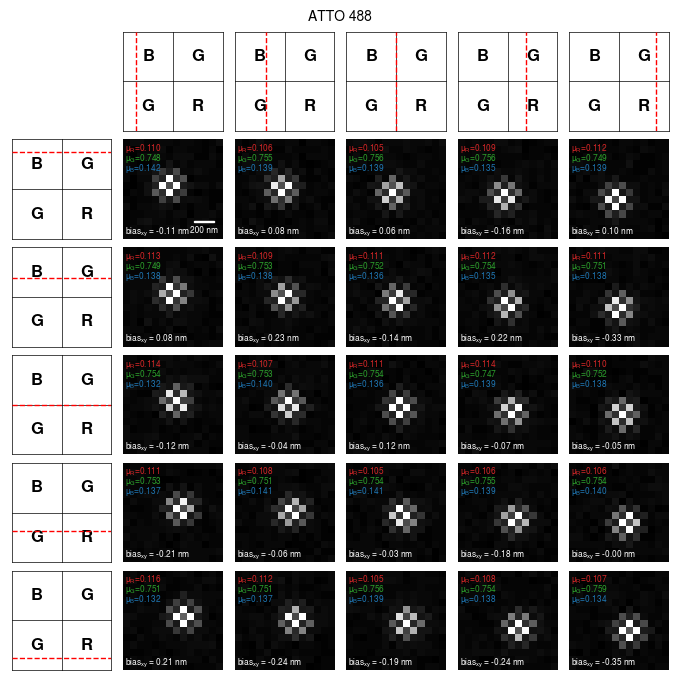

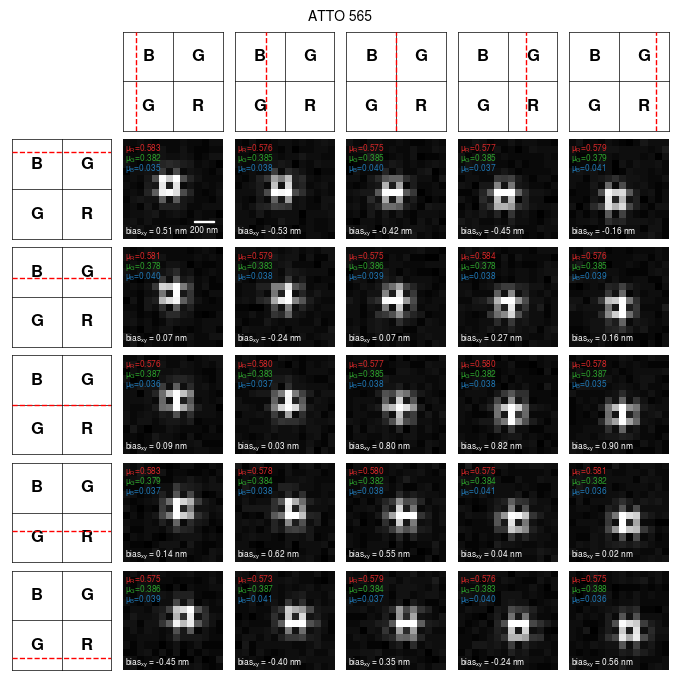

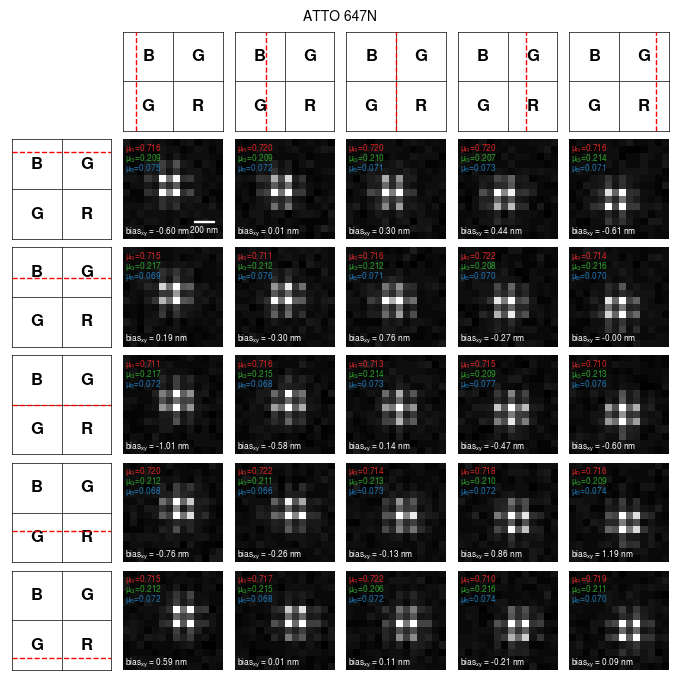

In [6]:
for dye in dyes:
    imgs = images_grid[dye]
    A = colour_results[dye]
    P = pos_results[dye]
    vmin, vmax = float(np.percentile(imgs, 1)), float(np.percentile(imgs, 99))

    fig = plt.figure(layout="constrained", figsize=(6.69, 6.69))
    gs = GridSpec(n_grid + 1, n_grid + 1, figure=fig)

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis("off")
            elif i == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, vline=border_vlines[j - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            elif j == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, hline=border_hlines[i - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            else:
                is_first = (i == 1 and j == 1)
                plotter.image_plot(
                    ax, imgs[i - 1, j - 1, :, :].T, cmap="gray", vmin=vmin, vmax=vmax,
                    colorbar=False, scalebar=is_first, pixelsize=pixel_size,
                    scalebarsize=200, scalebarlabel="200 nm", origin="upper",
                )
                ix_, iy_ = i - 1, j - 1
                mu_B = np.nanmean(A[ix_, iy_, :, 0])
                mu_G = np.nanmean(A[ix_, iy_, :, 1])
                mu_R = np.nanmean(A[ix_, iy_, :, 2])
                bias_xy = np.mean([np.nanmean(P[ix_, iy_, :, 0]), np.nanmean(P[ix_, iy_, :, 1])])

                for k, (text, color) in enumerate([
                    (r"$\mathrm{\mu_R}$=" + f"{mu_R:.3f}", "tab:red"),
                    (r"$\mathrm{\mu_G}$=" + f"{mu_G:.3f}", "tab:green"),
                    (r"$\mathrm{\mu_B}$=" + f"{mu_B:.3f}", "tab:blue"),
                ]):
                    ax.text(0.02, 0.98 - k * 0.10, text, transform=ax.transAxes,
                            fontsize=6, color=color, ha="left", va="top")
                ax.text(0.02, 0.02, r"bias$\mathrm{_{xy}}$ = " + f"{bias_xy:.2f} nm",
                        transform=ax.transAxes, fontsize=6, color="white", ha="left", va="bottom")

    fig.suptitle(dye, fontsize=10)
    plt.show()

## Figure: colour-ratio histograms per position

Each inner panel: per-channel histogram of the fitted colour fraction at that sub-pixel
position, with the per-channel mean annotated.

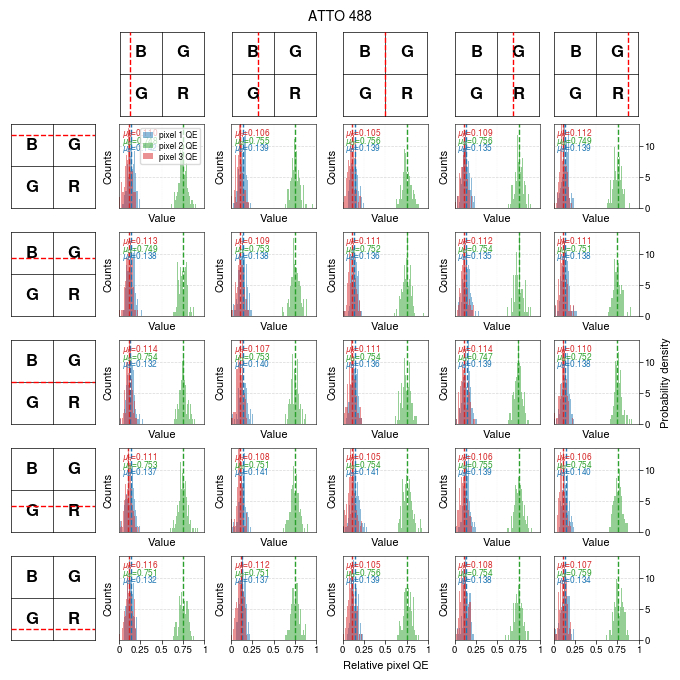

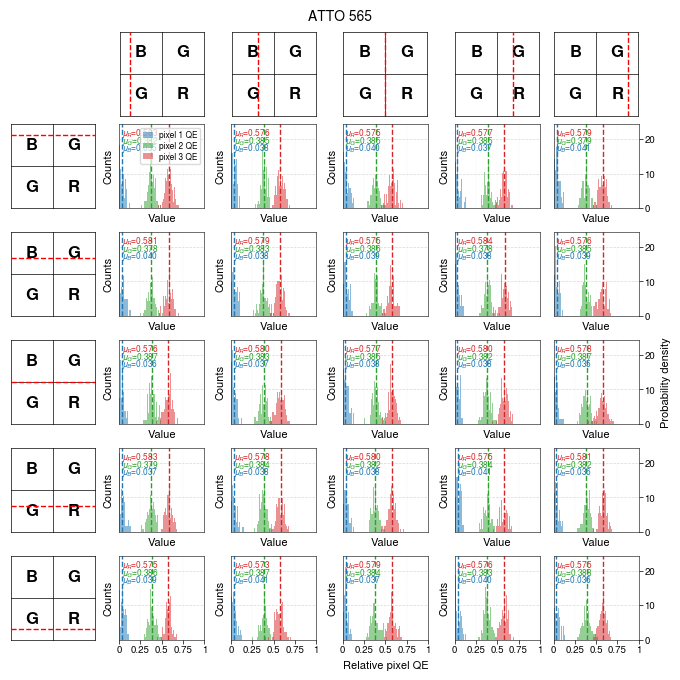

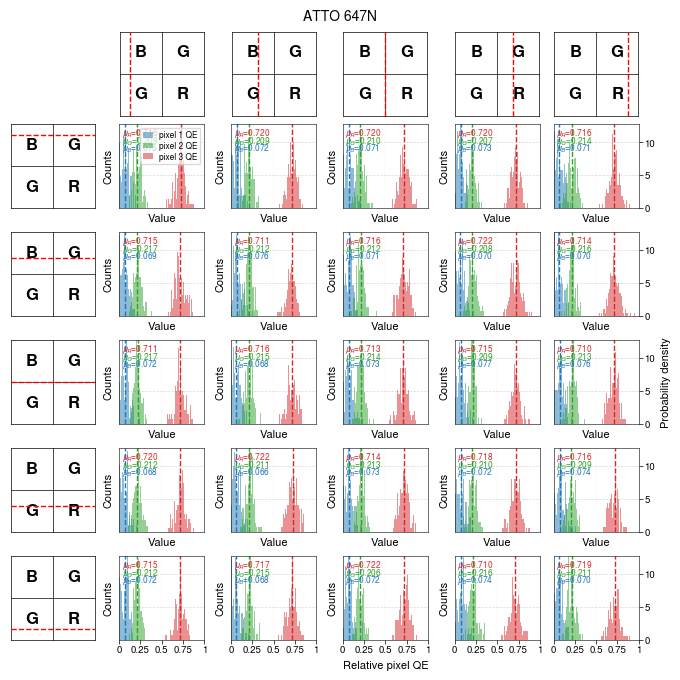

In [7]:
ch_colors = ["tab:blue", "tab:green", "tab:red"]
ch_labels = ["pixel 1 QE", "pixel 2 QE", "pixel 3 QE"]
hist_bins = 60 if FAST_MODE else 100
x_ticks = [0, 0.25, 0.5, 0.75, 1]
xlim = (0.0, 1.0)

for dye in dyes:
    A = colour_results[dye]

    max_density = 0.0
    for ix in range(n_grid):
        for iy in range(n_grid):
            for ch in range(3):
                counts, _ = np.histogram(A[ix, iy, :, ch][np.isfinite(A[ix, iy, :, ch])],
                                          bins=hist_bins, range=xlim, density=True)
                max_density = max(max_density, float(counts.max()))
    ylim = (0, max_density * 1.15)

    fig = plt.figure(layout="constrained", figsize=(6.69, 6.69))
    gs = GridSpec(n_grid + 1, n_grid + 1, figure=fig)

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis("off")
            elif i == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, vline=border_vlines[j - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            elif j == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, hline=border_hlines[i - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            else:
                ix_, iy_ = i - 1, j - 1
                for ch, (col, lbl) in enumerate(zip(ch_colors, ch_labels)):
                    vals = A[ix_, iy_, :, ch]
                    vals = vals[np.isfinite(vals)]
                    ax = plotter.histogram_plot(ax, vals, bins=hist_bins, density=True, color=col, alpha=0.5, label=lbl)
                    ax.vlines(x=np.median(vals), ls="--", lw=1, color=col, ymin=0, ymax=ylim[-1])

                for k, (ch, lbl, col) in enumerate([(2, "R", "tab:red"), (1, "G", "tab:green"), (0, "B", "tab:blue")]):
                    vals = A[ix_, iy_, :, ch]
                    vals = vals[np.isfinite(vals)]
                    mu = np.mean(vals)
                    ax.text(0.03, 0.97 - k * 0.09, rf"$\mu_{{{lbl}}}$={mu:.3f}",
                            transform=ax.transAxes, fontsize=6, color=col, ha="left", va="top")

                ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_axisbelow(True)
                ax.set_xticks(x_ticks)
                ax.grid(True, axis="x", linewidth=0.3, color="lightgray", zorder=0)
                if i == n_grid:
                    ax.set_xticklabels(["0", "0.25", "0.5", "0.75", "1"])
                    ax.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=7, pad=1, length=3)
                    ax.set_xlabel("Relative pixel QE" if j == 3 else "", fontsize=8)
                else:
                    ax.tick_params(axis="x", bottom=False, labelbottom=False, length=0)

                if j == n_grid:
                    ax.yaxis.tick_right(); ax.yaxis.set_label_position("right")
                    ax.tick_params(axis="y", right=True, labelright=True, left=False, labelleft=False, labelsize=7, pad=1, length=3)
                    ax.set_ylabel("Probability density" if i == 3 else "", fontsize=8)
                else:
                    ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False, length=0)

                if i == 1 and j == 1:
                    ax.legend(fontsize=6, loc="upper right", framealpha=0.7, handlelength=1.2, borderpad=0.3, labelspacing=0.2)
                elif ax.get_legend() is not None:
                    ax.get_legend().remove()

                for spine in ax.spines.values():
                    spine.set_linewidth(0.4)

    fig.suptitle(dye, fontsize=10)
    plt.show()

## Figure: position-bias histograms per position

Each inner panel: histograms of the x/y localisation-position residual (fitted minus
injected, nm) at that sub-pixel position.

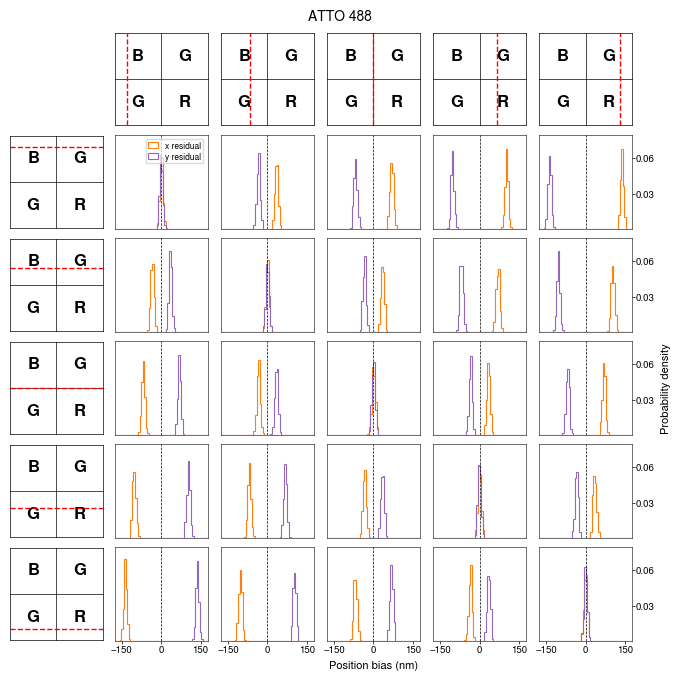

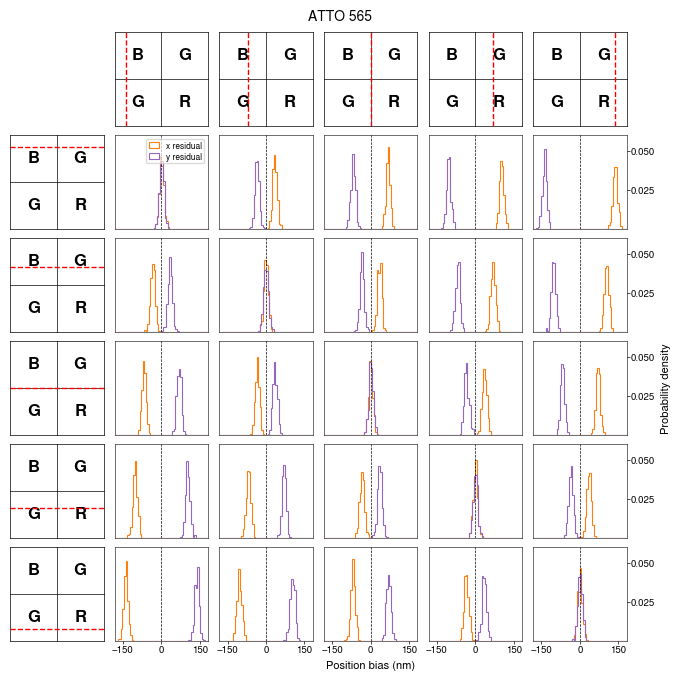

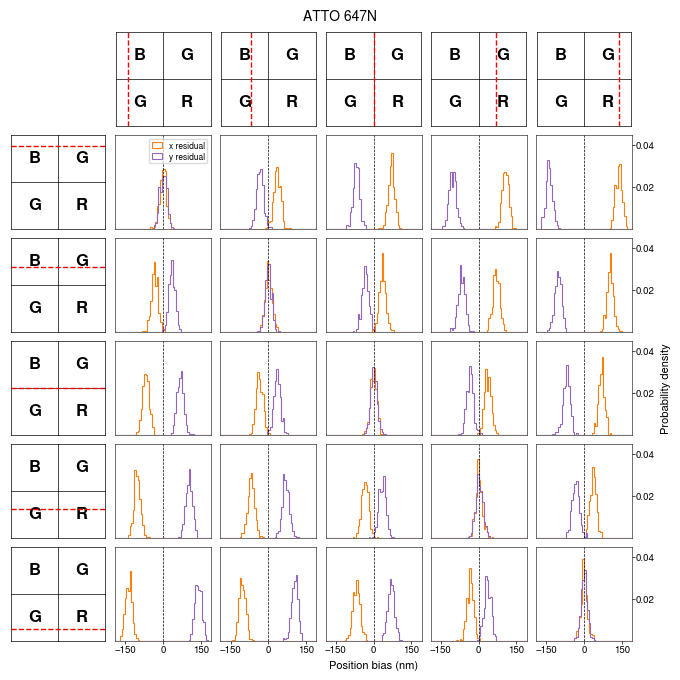

In [8]:
pos_colors = ["tab:orange", "tab:purple"]
pos_labels = ["x residual", "y residual"]

for dye in dyes:
    P = pos_results[dye]
    valid_abs = np.abs(P[np.isfinite(P)])
    lim = float(np.nanpercentile(valid_abs, 99.5)) * 1.2
    xlim = (-lim, lim)

    max_density = 0.0
    for ix in range(n_grid):
        for iy in range(n_grid):
            for ax_idx in range(2):
                vals = P[ix, iy, :, ax_idx]
                vals = vals[np.isfinite(vals)]
                counts, _ = np.histogram(vals, bins=hist_bins, range=xlim, density=True)
                max_density = max(max_density, float(counts.max()))
    ylim = (0, max_density * 1.15)

    fig = plt.figure(layout="constrained", figsize=(6.69, 6.69))
    gs = GridSpec(n_grid + 1, n_grid + 1, figure=fig)

    for i in range(n_grid + 1):
        for j in range(n_grid + 1):
            ax = fig.add_subplot(gs[i, j])

            if i == 0 and j == 0:
                ax.axis("off")
            elif i == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, vline=border_vlines[j - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            elif j == 0:
                plot_bayer_pattern(ax=ax, pattern="BGGR", size=2, hline=border_hlines[i - 1],
                                    fontsize=12, dark_background=False, line_color="red")
            else:
                ix_, iy_ = i - 1, j - 1
                for ax_idx, (col, lbl) in enumerate(zip(pos_colors, pos_labels)):
                    vals = P[ix_, iy_, :, ax_idx]
                    vals = vals[np.isfinite(vals)]
                    ax.hist(vals, bins=hist_bins, range=xlim, density=True, histtype="step",
                            color=col, linewidth=0.8, label=lbl)
                ax.axvline(0, color="k", linewidth=0.5, linestyle="--")

                ax.set_xlim(xlim); ax.set_ylim(ylim)
                if j == n_grid:
                    ax.yaxis.set_label_position("right"); ax.yaxis.tick_right()
                    ax.tick_params(axis="y", labelsize=7, pad=1)
                    ax.yaxis.set_major_locator(plt.MaxNLocator(3, prune="both"))
                    ax.set_ylabel("Probability density" if i == 3 else "", fontsize=8)
                else:
                    ax.set_yticks([])

                if i == n_grid:
                    ax.tick_params(axis="x", labelsize=7, pad=1)
                    ax.xaxis.set_major_locator(plt.MaxNLocator(3, prune="both"))
                    ax.set_xlabel("Position bias (nm)" if j == 3 else "", fontsize=8)
                else:
                    ax.set_xticks([])

                if i == 1 and j == 1:
                    ax.legend(fontsize=6, loc="upper right", framealpha=0.7, handlelength=1.2, borderpad=0.3, labelspacing=0.2)

                for spine in ax.spines.values():
                    spine.set_linewidth(0.4)

    fig.suptitle(dye, fontsize=10)
    plt.show()

## Next steps

Set `FAST_MODE = False` above and re-run for the published 10,000-fit-per-position
statistics (several minutes, no large output files — everything here stays in memory).